<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Intro_to_data_viz_II_matplotlib_scatter_plot_bar_plot_stacked_bar_pie_chart_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction to Data Visualization**
___




Data visualization is the presentation of data in an image or graphical format. Data visualization can also be defined as the discipline of understanding data by presenting it visually so that any patterns or trends, composition, comparisons, and relationships can be exposed.

We can use data visualization to explore data and find insights from it. We can also share our findings with others using data visualization. The human brain processes any information more easily using visualizations than spreadsheets or reports.

In [1]:
# data manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Scatter Plot**

A scatter plot, or dot diagram, consists of several data points plotted on two axes. Scatter plots help visualize two numeric variables. This type of plot can be used to identify correlation patterns or trends between variables.

The `plot()` method can also be used to create a scatter plot, but we need to include some additional information. Let's create a scatter plot of the monthly Matplotlib query with several "best fit" lines:

1. Create the scatter plot.
2. Convert to Matplotlib dates.
3. Add the best fit lines.
4. Label the axes, add a legend, and despine.
5. Format both the x- and y-axis tick labels.

In [2]:
stackoverflow_monthly = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTZ5fVQvljweLhF-lJPpiK0LQvkP0Wgplu4f3HhdGTSHRjz1YglYpx7isOv54Pd_BmW-4PeX4i2HntV/pub?gid=197735777&single=true&output=csv', parse_dates=True, index_col='creation_date')
stackoverflow_monthly

,pandas,matplotlib,numpy,seaborn,geopandas,geoviews,altair,yellowbrick,vega,holoviews,hvplot,bokeh
creation_date,,,,,,,,,,,,
2008-09-30,0,2,3,0,0,0,0,0,0,0,0,0
2008-10-31,0,0,2,0,0,0,0,0,0,0,0,0
2008-11-30,0,0,3,0,0,0,0,0,0,0,0,0
2008-12-31,0,2,4,0,0,0,0,0,0,0,0,0
2009-01-31,0,1,7,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-30,4335,1005,1351,209,62,0,28,4,17,7,2,59
2021-05-31,4217,824,1316,174,58,3,31,3,14,8,0,37
2021-06-30,4331,749,1214,166,66,0,44,2,25,8,4,38


#### `1. Create the scatter plot.`

So far, we've passed the x and y values as arguments to the `plot()` method; however, there's a third argument we haven't explored yet: the format string (`fmt`) is shorthand for specifying the marker (dot shape), linestyle, and color to be used for the plot. We can use this to create a scatter plot with the `plot()` method.

Note that while there's flexibility in the order in which these are specified, it's recommended that we specify them in the following order:

```python
fmt = '[marker][line][color]'
```

Here, we use the format string `ok` to create a scatter plot with a black circle (`o`) (`k`); note that we don't specify a linestyle because we don't want a line this time:

In [3]:
stackoverflow_monthly['matplotlib']

,matplotlib
creation_date,
2008-09-30,2
2008-10-31,0
2008-11-30,0
2008-12-31,2
2009-01-31,1
...,...
2021-04-30,1005
2021-05-31,824
2021-06-30,749


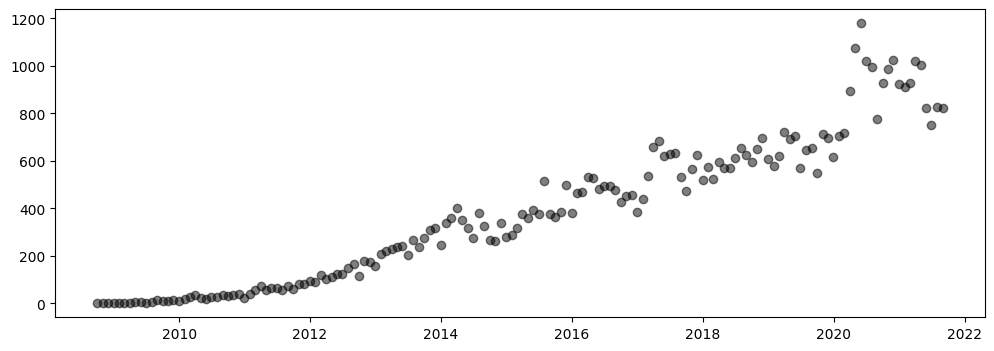

In [4]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
  stackoverflow_monthly.index, # x-axis
  stackoverflow_monthly['matplotlib'], # y-axis
  'ok', # format
  alpha=0.5 # transparency
)

plt.show()

*Tip: Alternatively, the `scatter()` method can be used to create a scatter plot, in which case we do not need to specify the format string (`fmt`).*

#### `2. Convert to Matplotlib dates.`

In the previous example, we used `stackoverflow_monthly.index` as the x-value. Although Matplotlib can display the year on the x-axis correctly, when we try to add best-fit lines, we run into problems. This is because Matplotlib handles dates a little differently. To get around this, we'll convert the dates to Matplotlib dates as we plot; then, at the end, we'll reformat them into a human-readable format.

We can use the `date2num()` function in the `matplotlib.dates` module to convert Matplotlib dates:

In [5]:
import matplotlib.dates as mdates

x_axis_dates = mdates.date2num(stackoverflow_monthly.index)
x_axis_dates[:5]

array([14152., 14183., 14213., 14244., 14275.])

Now, let's update our plot to use the following dates:

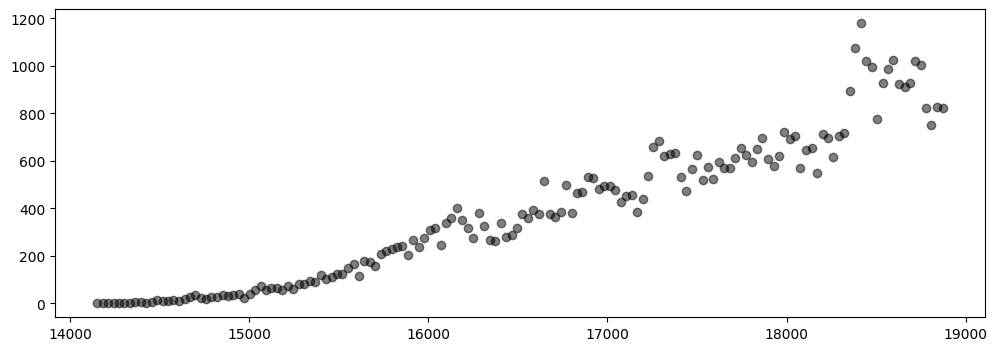

In [6]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
x_axis_dates, # x-axis
stackoverflow_monthly['matplotlib'], # y-axis
'ok', # format
alpha=0.5 # transparency
)

plt.show()

#### `3. Add the best fit lines.`

We will use NumPy to obtain the best fit lines, which are first- and second-degree polynomials. The `Polynomial.fit()` method fits a polynomial of a given degree to our data and returns a [Polynomial instance](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.html), which we will use to obtain the (x, y) points for creating the best fit lines:

```python
import numpy as np

degree = 1
poly = np.polynomial.Polynomial.fit(
  x_axis_dates, stackoverflow_monthly.matplotlib, degree
)
points = poly.linspace(n=100) # 100 evenly-spaced points along the domain
```

For each best fit line, we will call the `plot()` method to add it to the scatterplot:

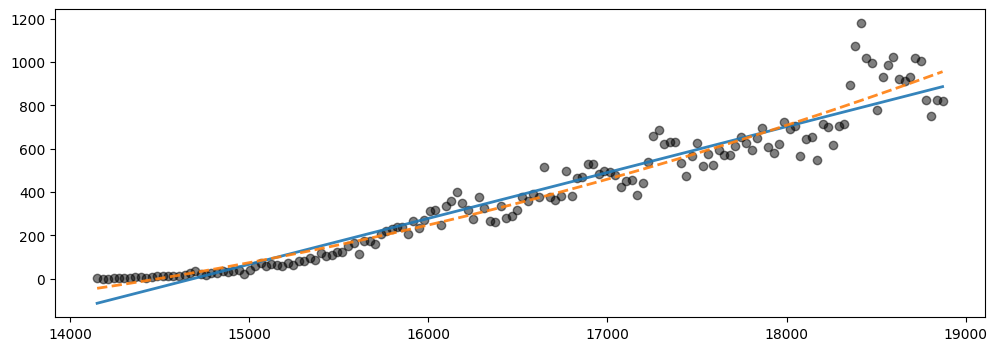

In [7]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
  x_axis_dates, # x-axis
  stackoverflow_monthly['matplotlib'], # y-axis
  'ok', # format
  alpha=0.5 # transparency
)

for degree, linestyle in zip([1, 2], ['solid', 'dashed']):

  poly = np.polynomial.Polynomial.fit(
    x_axis_dates, # x-axis
    stackoverflow_monthly['matplotlib'], # y-axis
  degree # degrees
  )

  ax.plot(
  *poly.linspace(), # parse x and y from fitting results
  label=degree, # label
  linestyle=linestyle, # line style
  linewidth=2, # line size
  alpha=0.9
  )

plt.show()

Before we continue, let's wrap this logic in a function:

In [8]:
def add_best_fit_line(ax, x, y):
  for degree, linestyle in zip([1, 2], ['solid', 'dashed']):

    poly = np.polynomial.Polynomial.fit(
    x, # x-axis
    y, # y-axis
    degree # degrees
    )

    ax.plot(
      *poly.linspace(), # parses x and y from the fitting results
      label=degree, # labels
      linestyle=linestyle, # linestyle
      linewidth=2, # linesize
      alpha=0.9
    )

    return ax

#### `4. Label the axes, add a legend, and despine.`

Next, we need to add a legend so we can distinguish the best-fit lines. Now is also a good time to label our axes, give our plot a title, and adjust the x- and y-axis limits (`xlim`/`ylim`). Here, we define a function that will add all of this to our plot and use the first date in the data as the start of the x-axis (we'll pass it as `xmin`):

In [9]:
def add_label(ax, xmin):
    ax.set(
        xlabel='creation date',
        ylabel='total question',
        xlim=(xmin, None),
        ylim=(0, None),
        title='Matplotlib Questions per Month\n(since the creation of Stack Overflow)'
    )
    ax.legend(title='degree')               # add legend and title of legend

    return ax


In [10]:
def despine(ax):
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    return ax

Let's call this function after the plotting code we've created so far and also define our plot:

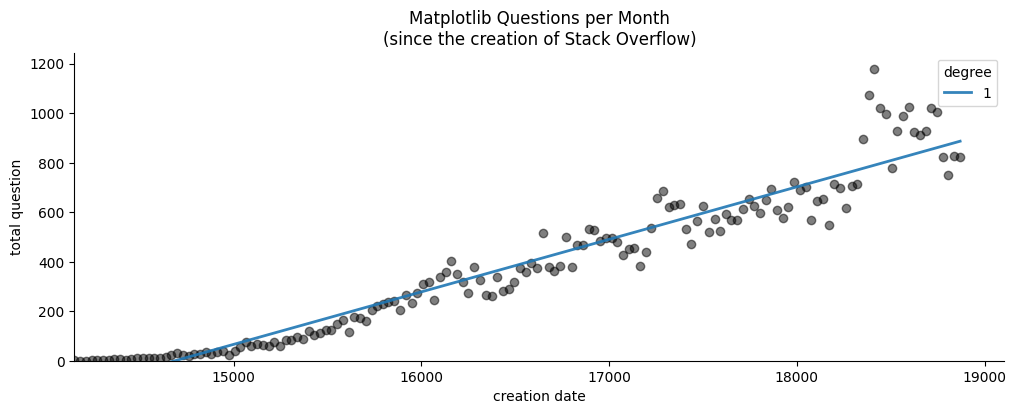

In [11]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
  x_axis_dates, # x-axis
  stackoverflow_monthly['matplotlib'], # y-axis
  'ok', # format
  alpha=0.5 # transparency
)

add_best_fit_line(ax, x_axis_dates, stackoverflow_monthly['matplotlib'])

add_label(ax, x_axis_dates[0])

despine(ax)

plt.show()

#### 5. Format both the x- and y-axis tick labels.

All that's left now is to clean up the tick labels on the axes: the x-axis should have human-readable dates, and the y-axis can be enhanced by formatting the numbers for readability. For both, we need to access the `Axis` object contained within the `Axes` object via the `xaxis`/`yaxis` attributes:

```python
ax.xaxis # access the x-axis
ax.yaxis # access the y-axis
```

From there, we'll use two methods to adjust the major tick labels (as opposed to minor ones, which our plot doesn't currently display). We'll call the set_major_locator() method to adjust the location of the ticks, and the set_major_formatter() method to adjust the format of the tick labels. For the x-axis, we'll space the ticks at 16-month intervals and format the labels as %b\n%Y, which places the month abbreviation above the year. This functionality comes from the matplotlib.dates module:

```python
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=16))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
```

The `matplotlib.ticker` module contains classes for locating and formatting ticks for non-date values. Here, we use the `StrMethodFormatter` class to provide a format string, as we saw with the `str.format()` method. This particular format specifies that the labels should be floating-point values with a comma as the thousands separator and zero digits after the decimal point:

```python
from matplotlib import tickers

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
```

Now, let's put it all together in a function:

In [12]:
from matplotlib import ticker

def format_axes(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=15))            # interval ticks per 16 (dalam hal ini bulan)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))            # memformat sumbu x menjadi tanggal
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))     # memformat sumbu y agar diberi thousand separator
    return ax

*Tip: Use `EngFormatter` instead of `StrMethodFormatter` for engineering notation.*

We now have all the pieces for the final visualization:

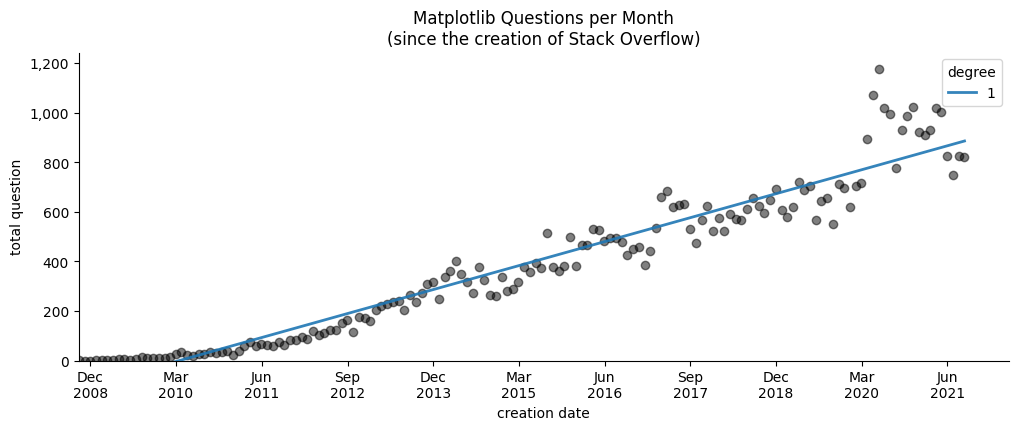

In [13]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(
  x_axis_dates, # x-axis
  stackoverflow_monthly['matplotlib'], # y-axis
  'ok', # format
  alpha=0.5 # transparency
)

# add best-fit line
add_best_fit_line(ax, x_axis_dates, stackoverflow_monthly['matplotlib'])

# add label
add_label(ax, x_axis_dates[0])

# remove borders above and to the right
despine(ax)

# format axes
format_axes(ax)

# display
plt.show()

## **2. Bar plot**

Bar plots are used to compare values (from a numeric column) between two or more groups (from a categorical column). The values being compared are usually aggregates, such as sums, averages, counts, and so on.

Before we delve into bar plots, we'll first try modifying the plot area we created earlier.

In [14]:
stackoverflow_daily_csv = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/stackoverflow_daily.csv'
stackoverflow_daily = pd.read_csv(stackoverflow_daily_csv, index_col='creation_date', parse_dates=True)
stackoverflow_daily.tail()

,pandas,matplotlib,numpy,seaborn,geopandas,geoviews,altair,yellowbrick,vega,holoviews,hvplot,bokeh
creation_date,,,,,,,,,,,,
2021-09-08,132,33,49,5,2,0,2,1,1,1,0,2
2021-09-09,182,33,51,8,1,0,1,0,3,0,0,2
2021-09-10,132,19,44,7,4,0,0,0,2,0,0,2
2021-09-11,66,19,17,2,1,0,0,0,0,0,0,1
2021-09-12,69,14,24,3,0,1,0,0,0,0,0,0


In [15]:
subset = stackoverflow_daily.sum().nlargest(4)
subset.index

Index(['pandas', 'numpy', 'matplotlib', 'seaborn'], dtype='object')

In [16]:
top_libraries_monthly = stackoverflow_monthly.reindex(columns=subset.index)
top_libraries_monthly.tail()

,pandas,numpy,matplotlib,seaborn
creation_date,,,,
2021-04-30,4335,1351,1005,209
2021-05-31,4217,1316,824,174
2021-06-30,4331,1214,749,166
2021-07-31,4170,1228,826,153
2021-08-31,4175,1095,822,170


In [17]:
def annotate(ax, data):
    total = 0
    for area in ax.collections:
        library = area.get_label()
        last = data.last('1D')[library]
        last_day, last_value = last.index[0], last.iat[0]
        if library != 'seaborn':
            kwargs = {}
        else:
            kwargs = dict(
                xytext=(last_day + pd.Timedelta(days=20), (last_value + total) * 1.1),
                arrowprops=dict(arrowstyle='->')
            )

        ax.annotate(
            f' {library}: {data.loc["2021", library].median():,.0f}',
            xy=(last_day, last_value / 2 + total), ha='left', va='center', **kwargs
        )
        total += last_value
    return ax

The top left area of the plot area we previously worked on has plenty of space. We can use this space to provide additional information with an inset plot. Let's work on adding an inset bar plot that displays the total questions per library:

1. Add the inset `Axes` object to the `Figure` object.
2. Create the horizontal bar plot.
3. Label and format the plot.

#### 1. Add the inset Axes object to the Figure object.

First, we need to modify the `area_plot()` function to also return a `Figure` object:

In [18]:
def area_plot(data):

    fig, ax = plt.subplots(figsize=(12,3))

    ax.stackplot(
        mdates.date2num(data.index),            # x axis
        data.to_numpy().T,                      # y axis
        labels = data.columns
    )

    ax.set(
        xlabel='',
        ylabel='tagged questions',
        title='Stack Overflow Questions per Month'
    )

    ax.yaxis.set_major_formatter(ticker.EngFormatter())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    despine(ax)
    annotate(ax, data)

    return fig, ax

Now, we can call the updated `area_plot()` function and use the `Figure` object it returns to add a plot inset via the `add_axes()` method. This method accepts dimensions as a series of four values, represented as percentages of the `Figure` dimension:
1. `left`: Offset from the left edge of the `Figure` (i.e., `x`).
2. `bottom`: Offset from the bottom edge of the `Figure` (i.e., `y`).
3. `width`: The width of the inset.
4. `height`: The height of the inset.

/tmp/ipython-input-17-1315594304.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last = data.last('1D')[library]


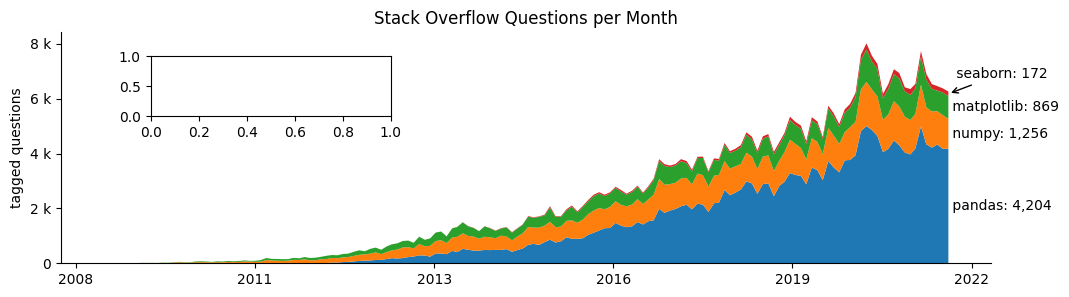

In [19]:
fig, ax = area_plot(top_libraries_monthly)
inset_ax = fig.add_axes([0.2, 0.6, 0.2, 0.2])

*Tip: Check the [axes_grid1 toolkit](https://matplotlib.org/stable/tutorials/toolkits/axes_grid.html#insetlocator) if you want the inset to contain a "zoomed in" version of the data.*

#### `2. Create the horizontal bar plot.`

Next, we use the `barh()` method to add horizontal bars to the insert. Each bar will represent the total number of questions for each library in the plot area, so we also need to ensure their colors align. To do this, we use the `collections` attribute to access each section of the plot area and retrieve its color with the `get_facecolor()` method:

In [20]:
total_qs = top_libraries_monthly.sum()
total_qs.index

Index(['pandas', 'numpy', 'matplotlib', 'seaborn'], dtype='object')

In [21]:
colors = {area.get_label(): area.get_facecolor() for area in ax.collections}
colors

{'pandas': array([[0.12156863, 0.46666667, 0.70588235, 1.        ]]),
 'numpy': array([[1.        , 0.49803922, 0.05490196, 1.        ]]),
 'matplotlib': array([[0.17254902, 0.62745098, 0.17254902, 1.        ]]),
 'seaborn': array([[0.83921569, 0.15294118, 0.15686275, 1.        ]])}

/tmp/ipython-input-17-1315594304.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last = data.last('1D')[library]


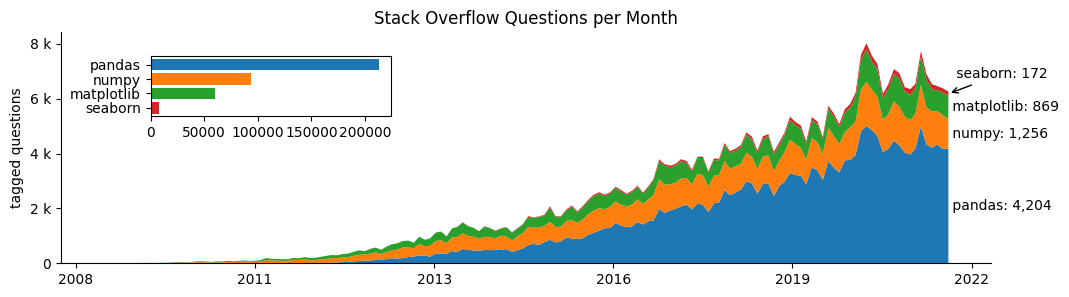

In [22]:
fig, ax = area_plot(top_libraries_monthly)
inset_ax = fig.add_axes([0.2, 0.6, 0.2, 0.2])
colors = {area.get_label(): area.get_facecolor() for area in ax.collections}

inset_ax.barh(
  total_qs.index, # index (y-axis)
  total_qs.values, # x-axis
  color=[colors[label] for label in total_qs.index]
)

inset_ax.yaxis.set_inverted(True) # sort in descending order

#### `3. Label and format the plot.`

Labeling and formatting the inset works the same way as we saw before:

/tmp/ipython-input-17-1315594304.py:5: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  last = data.last('1D')[library]


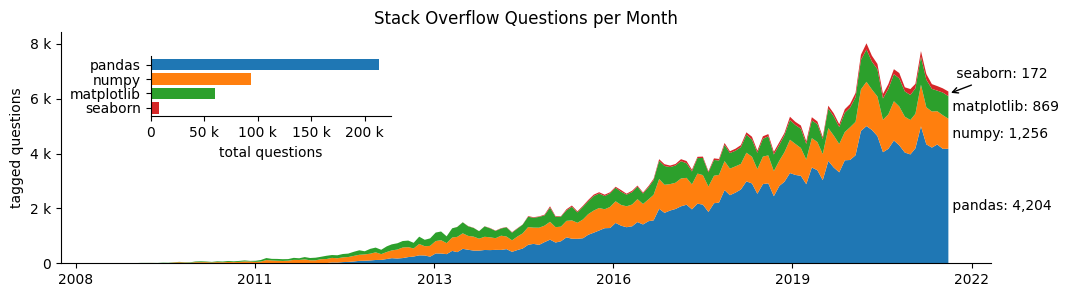

In [23]:
fig, ax = area_plot(top_libraries_monthly)
inset_ax = fig.add_axes([0.2, 0.6, 0.2, 0.2])
colors = {area.get_label(): area.get_facecolor() for area in ax.collections}

inset_ax.barh(
  total_qs.index, # index (y-axis)
  total_qs.values, # x-axis
  color=[colors[label] for label in total_qs.index]
)

inset_ax.yaxis.set_inverted(True) # sort in descending order

despine(inset_ax)
inset_ax.set_xlabel('total questions')
inset_ax.xaxis.set_major_formatter(ticker.EngFormatter())

plt.show()

A final comment on this example:

- More complex subplot layouts can be created with GridSpec or the Figure.subplot_mosaic() method, which was added in v3.3 to make it easier to create complex layouts.

#### **Annotating bars**

The inset we created only shows data for four libraries in the Stack Overflow dataset to fit the area plot. Due to the smaller scale of the other libraries, it doesn't make sense to include them in the area plot; however, we can visualize the total questions for each library with a bar plot if we use a log scale for the x-axis. This time, our bar plot isn't just an inset, and we'll learn how to annotate it.

In [25]:
questions_per_library = stackoverflow_daily.sum().sort_values()
print(questions_per_library)

yellowbrick        54
geoviews           63
hvplot             92
holoviews         542
vega              598
altair            804
geopandas        1652
bokeh            4386
seaborn          7414
matplotlib      60554
numpy           93797
pandas         214919
dtype: int64


#### `1. Create the bar plot.`
We once again use the `barh()` method to create a horizontal bar plot; however, note that the `bar()` method can also be used to create a vertical bar plot:

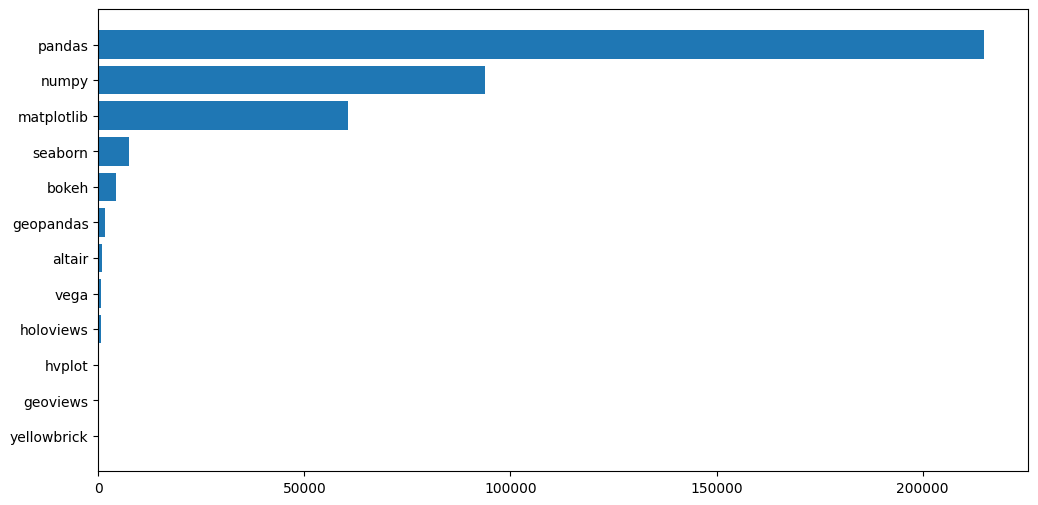

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    questions_per_library.index,
    questions_per_library.values
)

plt.show()

#### `2. Label, format, and apply a log scale to the plot.`
To change the axis scale, we specify values for `xscale`/`yscale` or pass values to the `set_xscale()`/`set_yscale()` methods::

```python
ax.set_xscale('log')
ax.set(xscale='log')
```

Now, we can see all the bars:

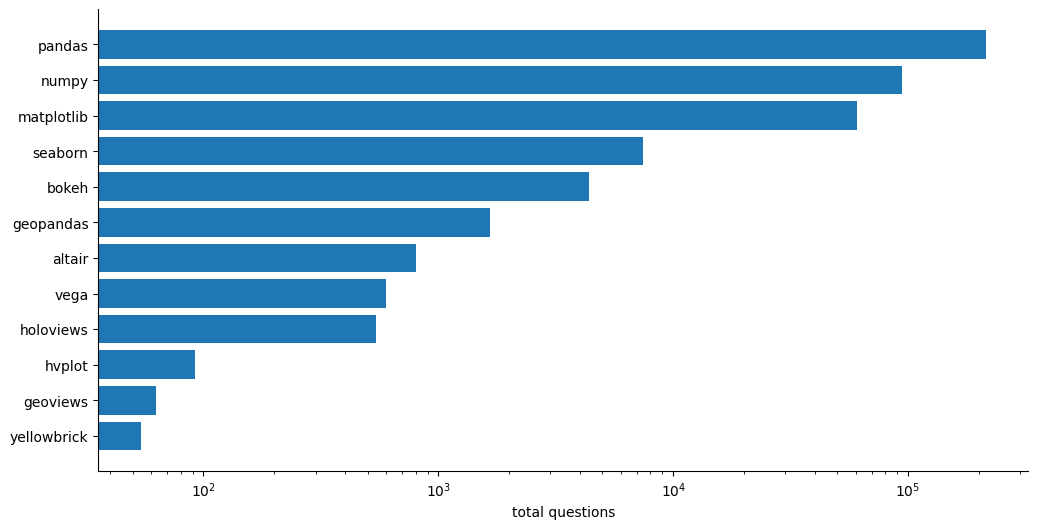

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    questions_per_library.index,
    questions_per_library.values
)

ax.set(
    xlabel='total questions',
    xscale='log'
)

despine(ax)

plt.show()

#### `3. Annotate each of the bars.`

To annotate a bar, we need to retrieve it from the `Axes` object, similar to how we retrieved the color from the area plot. To access the bars, we use the `patches` attribute. Here, we write a function to iterate over each of these patches and annotate each bar with the total number of queries for that library:

In [28]:
def annotate_bars(ax):
    for bar in ax.patches:
        x, y = bar.get_xy()
        ax.text(
            x + bar.get_width(), y + bar.get_height()/2, f'{bar.get_width():,d} ',
            va='center', ha='right', color='white'
        )
    return ax

When combined, our final visualization looks like this:

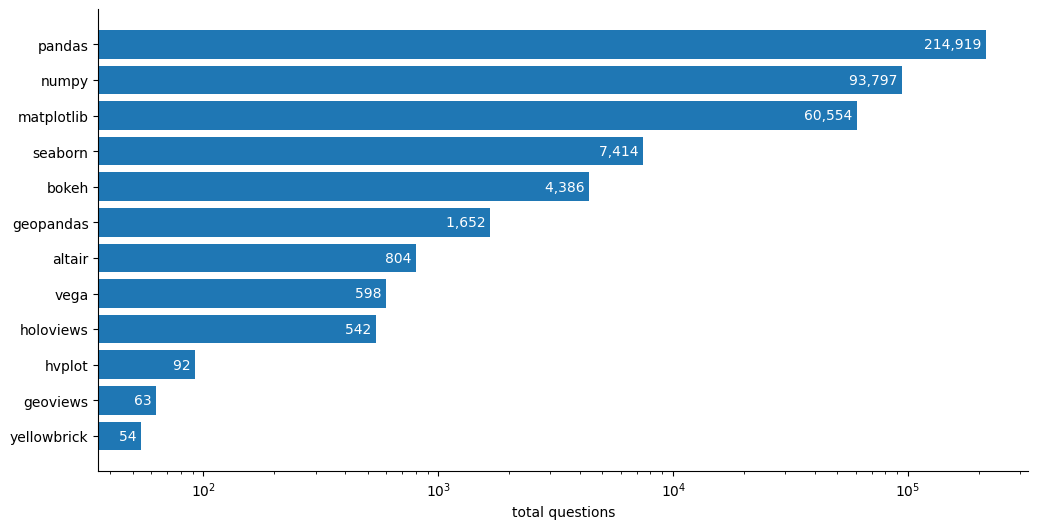

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    questions_per_library.index,
    questions_per_library.values
)

ax.set(
    xlabel='total questions',
    xscale='log'
)

despine(ax)

annotate_bars(ax)

plt.show()

## **3. Stacked Bar Plot**

For the next few examples, we'll create a stacked bar plot showing the co-occurrence of library tags. This gives us an idea of the relationships between libraries and how people use them. Our data looks like this. Here, we see that the largest co-occurrence with **hvplot** is **holoviews**, followed by **bokeh**.

In [30]:
stackoverflow_cooccurence_csv = 'https://raw.githubusercontent.com/harishmuh/Python-for-Data-Science-Analysis/refs/heads/main/datasets/stackoverflow_cooccurence.csv'
co_occur = pd.read_csv(stackoverflow_cooccurence_csv, index_col='library')

In [31]:
co_occur.style.background_gradient(axis=None, vmin=0, vmax=1)

,hvplot,geoviews,seaborn,holoviews,geopandas,matplotlib,numpy,bokeh,pandas
library,,,,,,,,,
hvplot,0.000000,0.032609,0.021739,0.539855,0.048913,0.023551,0.000000,0.110507,0.103261
geoviews,0.047619,0.000000,0.000000,0.431217,0.058201,0.039683,0.007937,0.140212,0.084656
seaborn,0.000270,0.000000,0.000000,0.000135,0.000607,0.468033,0.015871,0.002001,0.230780
holoviews,0.091636,0.050123,0.001845,0.000000,0.003075,0.030750,0.010148,0.371771,0.066113
geopandas,0.002724,0.002220,0.002724,0.001009,0.000000,0.118644,0.009988,0.011703,0.250504
matplotlib,0.000036,0.000041,0.057304,0.000275,0.003237,0.000000,0.087198,0.001594,0.135548
numpy,0.000000,0.000005,0.001254,0.000059,0.000176,0.056294,0.000000,0.000144,0.167267
bokeh,0.002318,0.002014,0.003382,0.045942,0.004408,0.022002,0.003078,0.000000,0.087855
pandas,0.000044,0.000025,0.007961,0.000167,0.001926,0.038191,0.073000,0.001793,0.000000


*Tip: To learn more about DataFrames styles, see the pandas documentation [here](https://pandas.pydata.org/docs/user_guide/style.html).*

Note that the diagonal contains zeros because we also want to understand what percentage of questions per library are also tagged with other libraries in this dataset. For example, most questions tagged with **hvplot** or **geoviews** are also tagged with other libraries in our list, but questions tagged with **pandas** are only tagged with other libraries 12.3% of the time:

In [33]:
print(co_occur.sum(axis=1))

library
hvplot        0.880435
geoviews      0.809524
seaborn       0.717696
holoviews     0.625461
geopandas     0.399516
matplotlib    0.285233
numpy         0.225199
bokeh         0.170999
pandas        0.123107
dtype: float64


In this example, we'll also look at another way to format axes with tickers and learn how to customize the colors. Let's follow these steps:
1. Create the stacked bar plot.
2. Add the legend.
3. Label and format the plot.
4. Annotate the bars.
5. Change the color scheme.

#### `1. Create the stacked bar plot.`

To create a stacked bar plot, we can still use the `barh()` method; however, we'll need to make multiple calls to that function, each time determining where the starting point should be (i.e., the end of the previous bar section). We'll wrap this logic in a function:

In [34]:
co_occur.index

Index(['hvplot', 'geoviews', 'seaborn', 'holoviews', 'geopandas', 'matplotlib',
       'numpy', 'bokeh', 'pandas'],
      dtype='object', name='library')

In [35]:
def stacked_bars(data):

    fig, ax = plt.subplots(figsize=(12,6))
    libraries = data.index

    last = 0
    for library in libraries:
        ax.barh(
            data.index,                # index
            data[library],             # x axis
            label=library,
            left=last
        )
        last += data[library]

    ax.yaxis.set_inverted(True)

    return despine(ax)


Calling our function gives us the beginnings of a stacked bar plot visualization:

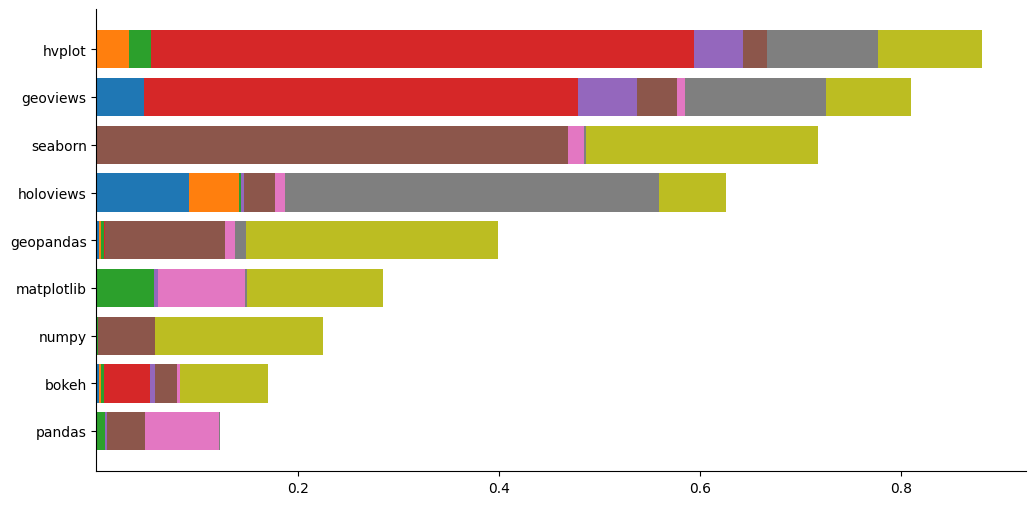

In [36]:
ax = stacked_bars(co_occur)

#### `2. Add the legend.`

Next, we add a legend to understand the meaning of the colors:

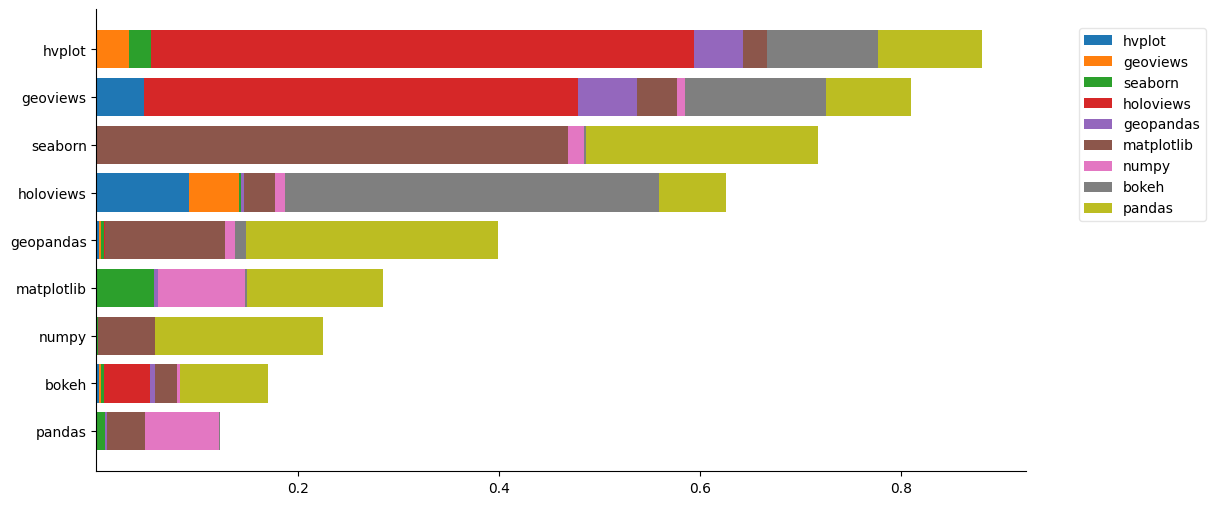

In [37]:
ax = stacked_bars(co_occur)
ax.legend(loc='center right', framealpha=0.5, bbox_to_anchor=(1.2, 0.75))
plt.show()

#### `3. Label and format the plot.`

Next, we label the x-axis and set the x-axis limit (`xlim`) so that it changes from 0% to 100%. We also use `ticker.PercentFormatter` to display the x-axis tick labels as percentages. Note that we passed `xmax=1` when creating the instance because our data already contains percentages, but passing in the maximum value in the data will calculate the percentage:

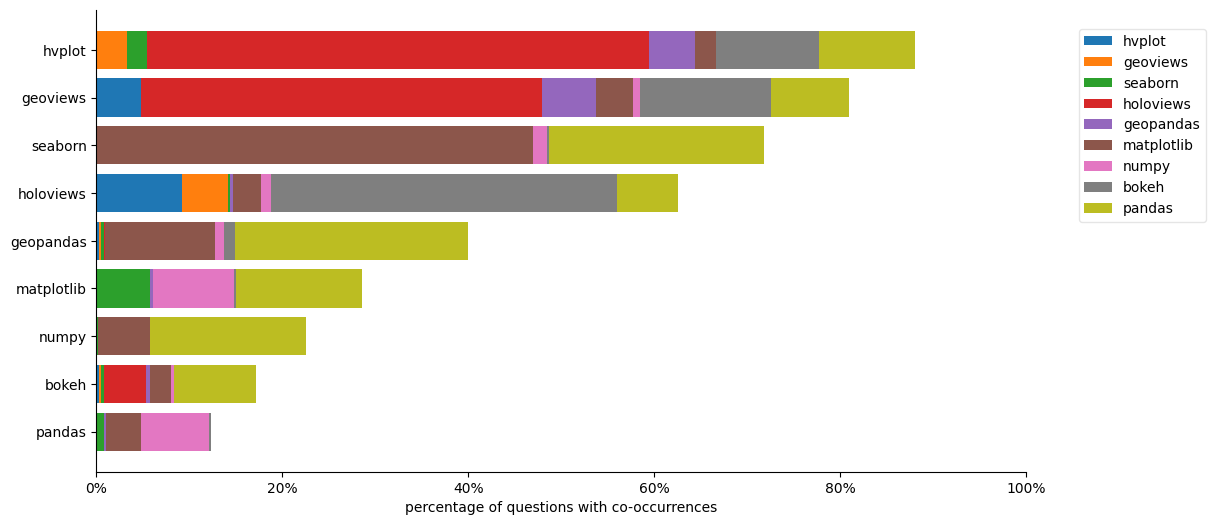

In [38]:
ax = stacked_bars(co_occur)

ax.legend(loc='center right', framealpha=0.5, bbox_to_anchor=(1.2, 0.75))
ax.set(
    xlabel='percentage of questions with co-occurrences',
    xlim=(0,1)
)

ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.show()

Before we continue, let's update our function to include what we have so far:

In [39]:
def stacked_bars(data):

    fig, ax = plt.subplots(figsize=(12,6))
    libraries = data.index

    last = 0
    for library in libraries:
        ax.barh(
            data.index,                # index
            data[library],             # x axis
            label=library,
            left=last
        )
        last += data[library]

    ax.yaxis.set_inverted(True)

    ax.legend(loc='center right', framealpha=0.5, bbox_to_anchor=(1.2, 0.75))
    ax.set(
        xlabel='percentage of questions with co-occurrences',
        xlim=(0,1)
    )

    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

    return despine(ax)

#### `4. Annotate the bars.`

Like the previous example, we annotate our bars after accessing each bar via the `patches` attribute on the `Axes` object. However, this time we only label bars whose values exceed a threshold – note that the bar value here is its width:

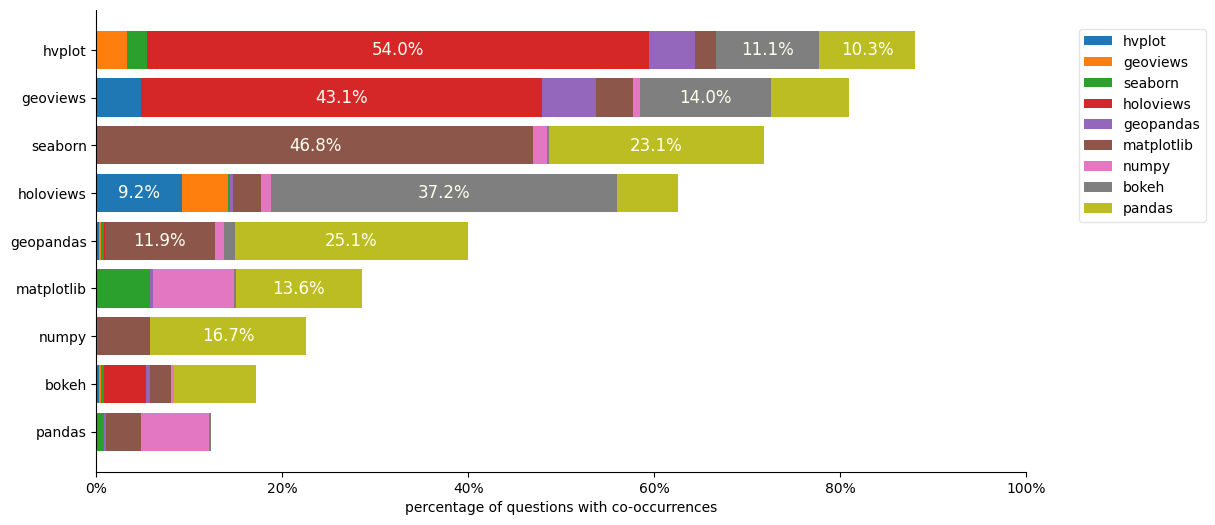

In [40]:
ax = stacked_bars(co_occur)

for patch in ax.patches:
    width = patch.get_width()
    if width >= 0.09:
        ax.text(
            patch.get_x() + width/2,
            patch.get_y() + patch.get_height()/2,
            f'{width:.1%}',
            color='ivory',
            fontsize=12,
            ha='center',
            va='center'
        )

Let's wrap up the annotation logic before continuing:

In [41]:
def annotate_bars(ax, threshold):
    for patch in ax.patches:
        width = patch.get_width()
        if width >= threshold:
            ax.text(
                patch.get_x() + width/2,                    # x position
                patch.get_y() + patch.get_height()/2,       # y position
                f'{width:.1%}',                             # Writing format
                color='ivory',                              # color
                fontsize=12,                                # font size
                ha='center',
                va='center'
            )

#### 5. Change the color scheme.

Throughout this workshop, we've been using default color maps. For this visualization, we'll take a look at how to change the color map. Note that this is only one way of working with color maps.

So far, we've been using default color maps. For this visualization, we'll look at how to change the color map. Note that this is just one way of working with color maps.

For this example, we will choose the qualitative colormap `tab10` and reverse the order:

In [42]:
import matplotlib as mpl

cmap = mpl.colormaps['tab10'].reversed()

*Note: The colormap we chose is the default colormap, but flipping it will change the order in which the colors are assigned. Since we have nine elements and ten colors, this time we will look at a new color. See the full list of colormaps here.*

The colormap object is a **callable**:

In [43]:
[cmap(i) for i in range(10)]

[(np.float64(0.09019607843137255),
  np.float64(0.7450980392156863),
  np.float64(0.8117647058823529),
  np.float64(1.0)),
 (np.float64(0.7372549019607844),
  np.float64(0.7411764705882353),
  np.float64(0.13333333333333333),
  np.float64(1.0)),
 (np.float64(0.4980392156862745),
  np.float64(0.4980392156862745),
  np.float64(0.4980392156862745),
  np.float64(1.0)),
 (np.float64(0.8901960784313725),
  np.float64(0.4666666666666667),
  np.float64(0.7607843137254902),
  np.float64(1.0)),
 (np.float64(0.5490196078431373),
  np.float64(0.33725490196078434),
  np.float64(0.29411764705882354),
  np.float64(1.0)),
 (np.float64(0.5803921568627451),
  np.float64(0.403921568627451),
  np.float64(0.7411764705882353),
  np.float64(1.0)),
 (np.float64(0.8392156862745098),
  np.float64(0.15294117647058825),
  np.float64(0.1568627450980392),
  np.float64(1.0)),
 (np.float64(0.17254901960784313),
  np.float64(0.6274509803921569),
  np.float64(0.17254901960784313),
  np.float64(1.0)),
 (np.float64(1.0),

*Tip: to learn more about callables [here](https://www.pythonmorsels.com/topics/callables/).*

This means that when we update the `stacked_bars()` function to accept a colormap, we also need to update the `for` loop:

In [44]:
def stacked_bars(data, color):

    fig, ax = plt.subplots(figsize=(12,6))
    libraries = data.index
    cmap = mpl.colormaps[color].reversed()

    last = 0
    for i, library in enumerate(libraries):
        ax.barh(
            data.index,                # index
            data[library],             # x axis
            label=library,
            left=last,
            color=cmap(i)
        )
        last += data[library]

    ax.yaxis.set_inverted(True)

    ax.legend(loc='center right', framealpha=0.5, bbox_to_anchor=(1.2, 0.75))
    ax.set(
        xlabel='percentage of questions with co-occurrences',
        xlim=(0,1)
    )

    ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

    return despine(ax)

Calling the updated function with the reversed colormap will change the color on each bar:

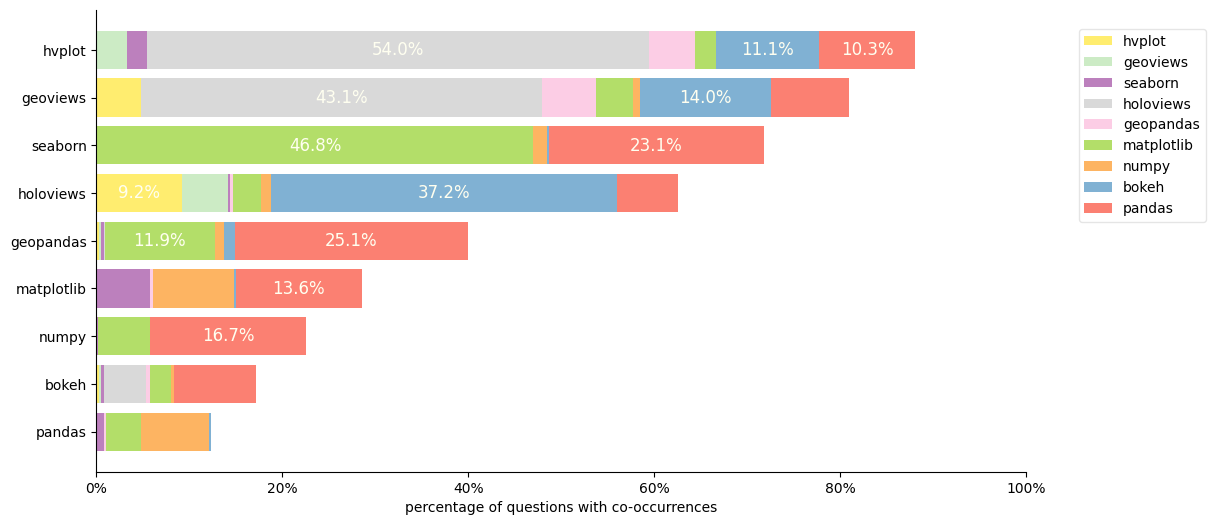

In [45]:
ax = stacked_bars(co_occur, 'Set3')
annotate_bars(ax, 0.09)

## **4. Pie Chart**

Besides using bar plots, we can also see the relationship between categorical and numerical variables using pie charts. Pie charts can be used to display proportions/percentages across groups. However, try to avoid using pie charts, especially if there are too many unique values in the categorical column.

In this case, we will create a pie chart to display the proportions of the four most frequently asked libraries on Stack Overflow.

In [47]:
print(subset)

pandas        214919
numpy          93797
matplotlib     60554
seaborn         7414
dtype: int64


To create a pie chart, we can use the `pie()` method.

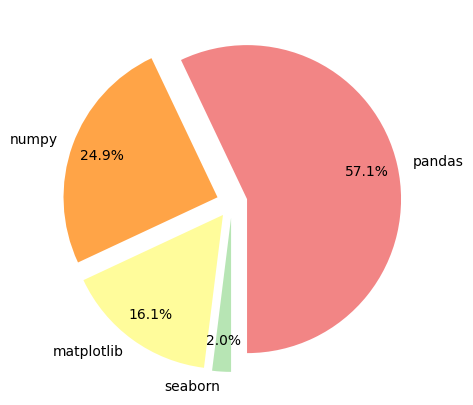

In [48]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    subset,                 # series
    labels=subset.index,    # label
    autopct='%1.1f%%',      # annotation
    colors=['#F28585', '#FFA447', '#FFFC9B', '#B7E5B4'],
    startangle=270,
    pctdistance=0.8,        # annotation position
    explode=[0.1, 0.1, 0.1, 0.1]
)

plt.show()

Next, we can change it into a donut shape by adding a white circle in the middle using the `add_artist()` method.

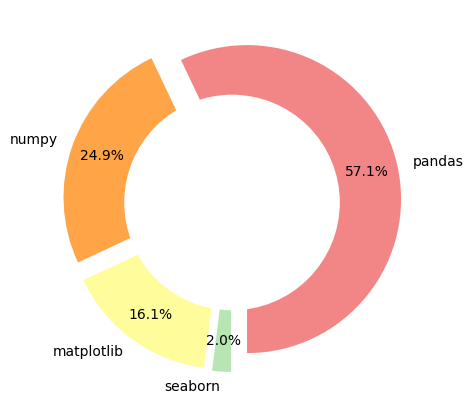

In [49]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    subset,                 # series
    labels=subset.index,    # label
    autopct='%1.1f%%',      # annotation
    colors=['#F28585', '#FFA447', '#FFFC9B', '#B7E5B4'],
    startangle=270,
    pctdistance=0.8,        # annotation position
    explode=[0.1, 0.1, 0.1, 0.1]
)

# add a circle in the middle
fig = plt.gcf()
centre_circle = plt.Circle((0,0), 0.7, fc='white')      # Circle((x, y), radius, fc/color)
fig.gca().add_artist(centre_circle)

plt.show()

To make it more beautiful, we can add a title and description to the graph.

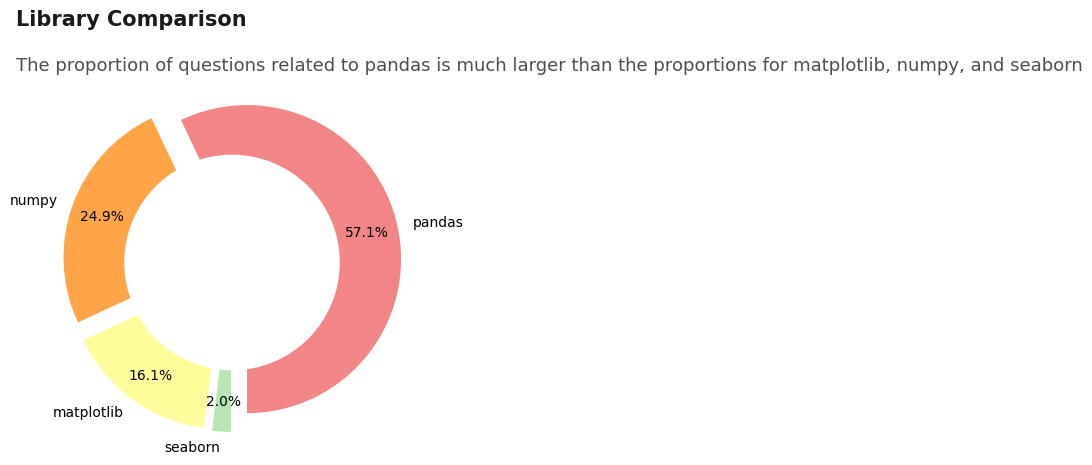

In [51]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    subset, # series
    labels=subset.index, # label
    autopct='%1.1f%%', # annotation
    colors=['#F28585', '#FFA447', '#FFFC9B', '#B7E5B4'],
    startangle=270,
    pctdistance=0.8, # annotation position
    explode=[0.1, 0.1, 0.1, 0.1]
)

# Add a circle to the center
centre_circle = plt.Circle((0,0), 0.7, fc='white') # Circle((x, y), radius, fc/color)
ax.add_artist(centre_circle)

# Add a title and Description

fig.text(
    0.08,
    0.97,
    "Library Comparison",
    color='#1a1a1a',
    fontsize=15,
    weight='bold'
)

fig.text(
    0.08,
    0.88,
    "The proportion of questions related to pandas is much larger than the proportions for matplotlib, numpy, and seaborn",
    color='#4d4d4d',
    fontsize=13,
    ha='left'
)

plt.show()

## **5. Heatmap**

A heatmap is a data visualization technique that shows the magnitude of a phenomenon through the colors displayed. A heatmap contains values represented by specific colors in a plot. Typically, darker colors in a graph indicate higher values than lighter ones. The reverse can also be true. For significantly different values, different colors can also be used.

In the previous case, we created a stacked bar plot showing the co-occurrence of library tags in the following data:

In [52]:
co_occur.style.background_gradient(axis=None, vmin=0, vmax=1)

,hvplot,geoviews,seaborn,holoviews,geopandas,matplotlib,numpy,bokeh,pandas
library,,,,,,,,,
hvplot,0.000000,0.032609,0.021739,0.539855,0.048913,0.023551,0.000000,0.110507,0.103261
geoviews,0.047619,0.000000,0.000000,0.431217,0.058201,0.039683,0.007937,0.140212,0.084656
seaborn,0.000270,0.000000,0.000000,0.000135,0.000607,0.468033,0.015871,0.002001,0.230780
holoviews,0.091636,0.050123,0.001845,0.000000,0.003075,0.030750,0.010148,0.371771,0.066113
geopandas,0.002724,0.002220,0.002724,0.001009,0.000000,0.118644,0.009988,0.011703,0.250504
matplotlib,0.000036,0.000041,0.057304,0.000275,0.003237,0.000000,0.087198,0.001594,0.135548
numpy,0.000000,0.000005,0.001254,0.000059,0.000176,0.056294,0.000000,0.000144,0.167267
bokeh,0.002318,0.002014,0.003382,0.045942,0.004408,0.022002,0.003078,0.000000,0.087855
pandas,0.000044,0.000025,0.007961,0.000167,0.001926,0.038191,0.073000,0.001793,0.000000


Now we will try to create a heatmap from the same data using the `imshow()` method.

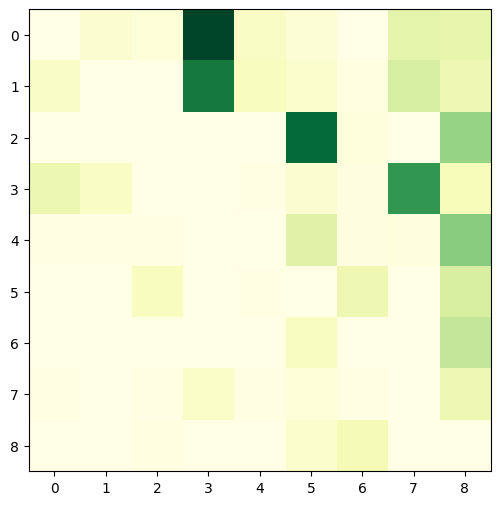

In [53]:
# Creating heatmap
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(co_occur.values, cmap='YlGn')

Next we will display each tick and label it according to the library in the data.

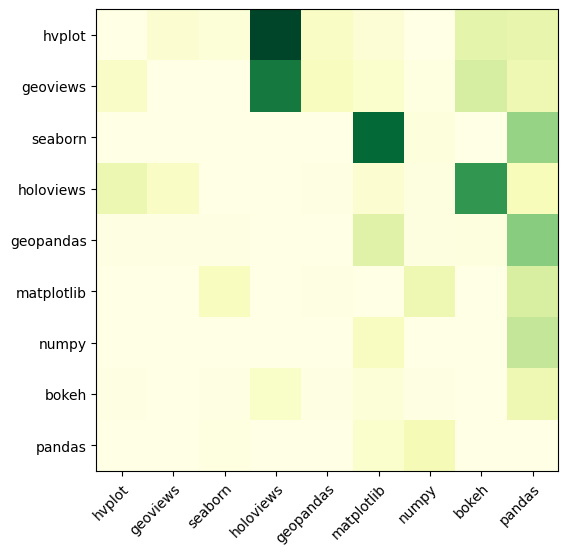

In [54]:
# create heatmap
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(co_occur.values, cmap='YlGn')

# label
ax.set_yticks(np.arange(len(co_occur.index)), labels=co_occur.index)
ax.set_xticks(np.arange(len(co_occur.columns)), labels=co_occur.columns)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

plt.show()

So that the value of each box can be seen clearly, we will display annotations on the graph by looping each value in the data and displaying it in text form:

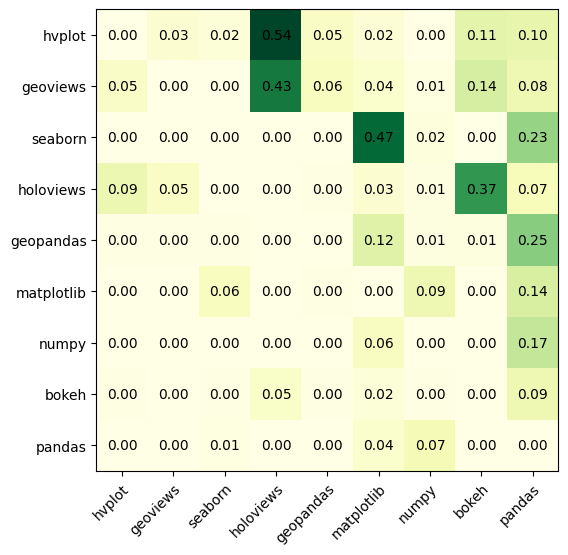

In [55]:
# create heatmap
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(co_occur.values, cmap='YlGn')

# label
ax.set_yticks(np.arange(len(co_occur.index)), labels=co_occur.index)
ax.set_xticks(np.arange(len(co_occur.columns)), labels=co_occur.columns)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# annotate
for i in range(len(co_occur.index)):
  for j in range(len(co_occur.columns)):
    text = ax.text(j, i, f'{co_occur.iloc[i, j]:.2f}', ha='center', va='center')

plt.show()

To beautify the final appearance, we can add a title and colorbar.

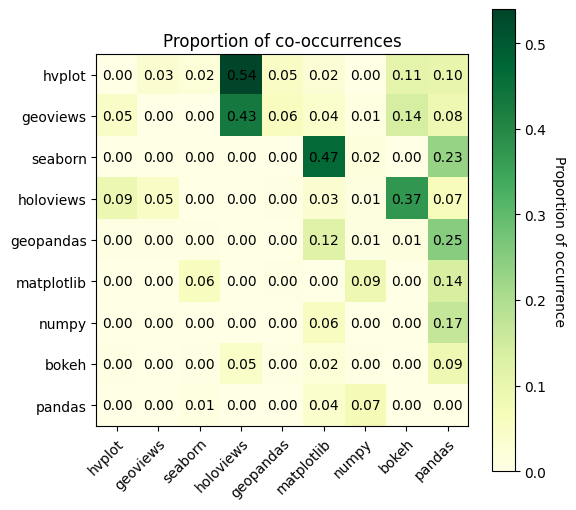

In [56]:
# create heatmap
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(co_occur.values, cmap='YlGn')

# label
ax.set_yticks(np.arange(len(co_occur.index)), labels=co_occur.index)
ax.set_xticks(np.arange(len(co_occur.columns)), labels=co_occur.columns)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

# annotate
for i in range(len(co_occur.index)):
  for j in range(len(co_occur.columns)):
    text = ax.text(j, i, f'{co_occur.iloc[i, j]:.2f}', ha='center', va='center')

# add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Proportion of occurrence", rotation=-90, va='bottom')

ax.set_title('Proportion of co-occurrences')

plt.show()

## **6. Plotting with Seaborn**

Seaborn is a library for creating graphs and statistics using Python. This library is built on the matplotlib library and integrated with data structures in pandas.

We can use Seaborn to create several graphs, including:

In [57]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### `Histogram`

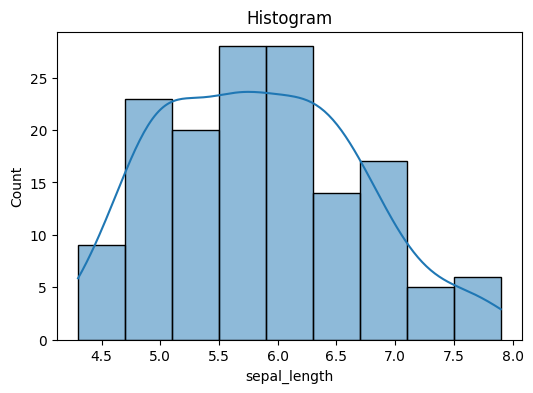

In [58]:
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.histplot(data=df, x='sepal_length', kde=True)
ax.set_title('Histogram')
plt.show()

### `Boxplot`

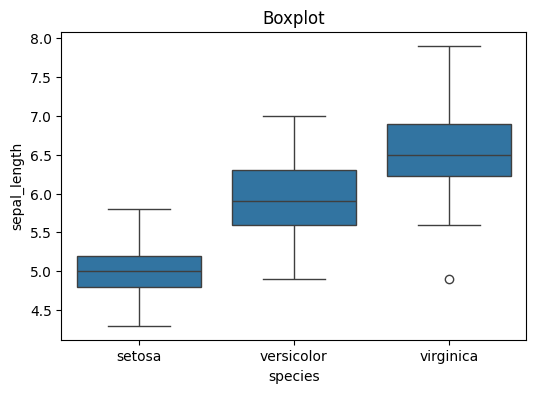

In [59]:
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.boxplot(data=df, y='sepal_length', x='species')
ax.set_title('Boxplot')
plt.show()

### `Violin plot`

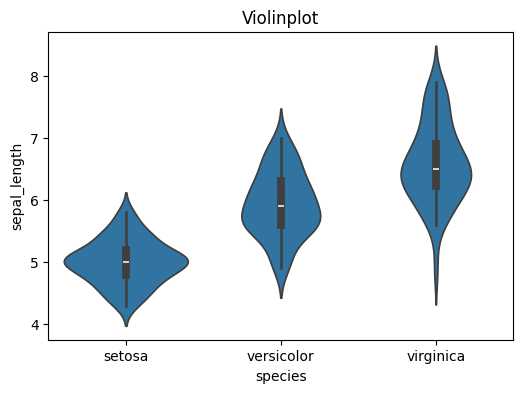

In [60]:
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.violinplot(data=df, y='sepal_length', x='species')
ax.set_title('Violinplot')
plt.show()

### `Barplot`

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.barplot(data=df, y='sepal_length', x='species', estimator=np.mean)
ax.set_title('Bar plot')
plt.show()

# by default uses mean

### `Countplot`

In [61]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


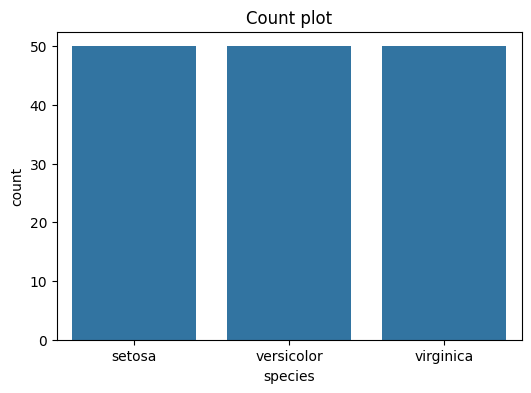

In [62]:
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.countplot(data=df, x='species')
ax.set_title('Count plot')
plt.show()

### `Scatterplot`

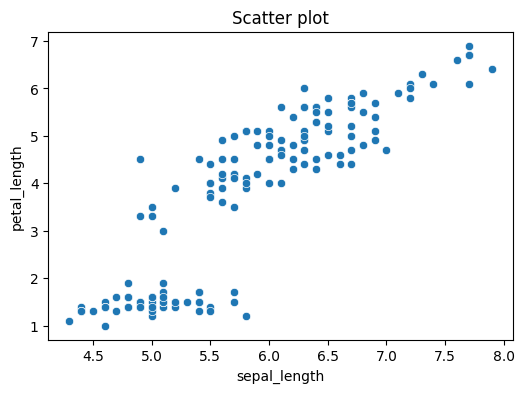

In [63]:
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.scatterplot(data=df, x='sepal_length', y='petal_length')
ax.set_title('Scatter plot')
plt.show()

### `Regplot`

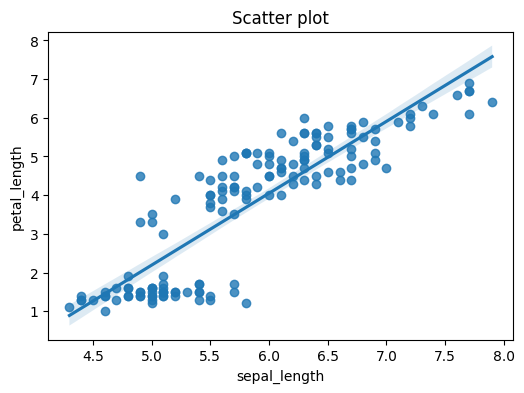

In [64]:
fig, ax = plt.subplots(figsize=(6,4))
ax = sns.regplot(data=df, x='sepal_length', y='petal_length')
ax.set_title('Scatter plot')
plt.show()

### `Jointplot`

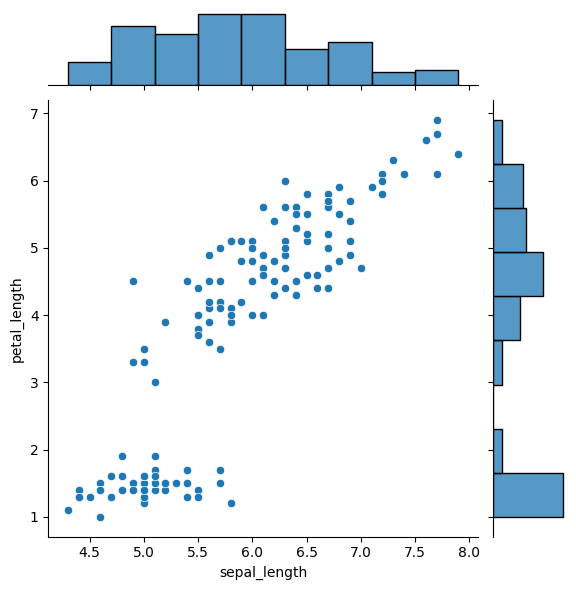

In [65]:
sns.jointplot(data=df, x='sepal_length', y='petal_length', kind='scatter')
plt.show()

### `Pairplot`

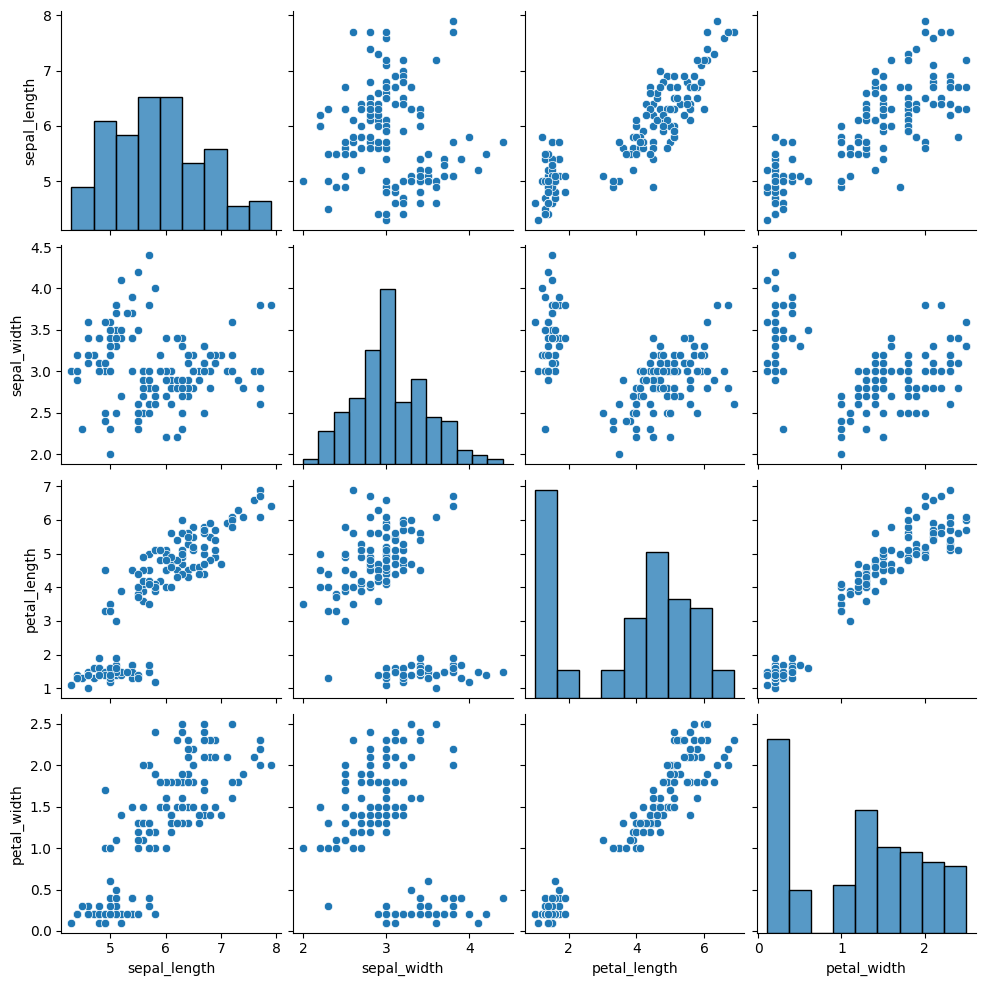

In [66]:
sns.pairplot(df)
plt.show()

### `Heatmap`

In [68]:
df.corr(method='spearman', numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.166778,0.881898,0.834289
sepal_width,-0.166778,1.000000,-0.309635,-0.289032
petal_length,0.881898,-0.309635,1.000000,0.937667
petal_width,0.834289,-0.289032,0.937667,1.000000


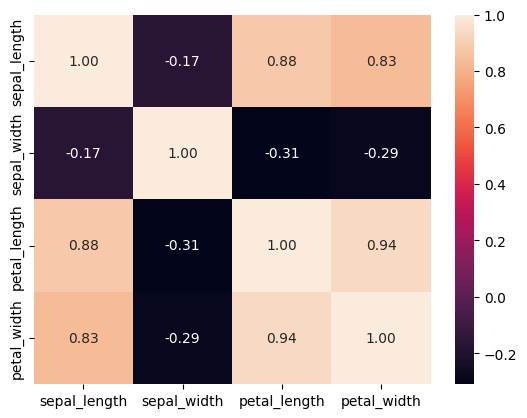

In [71]:
sns.heatmap(df.corr(method='spearman', numeric_only=True),  annot=True, fmt='.2f')
plt.show()